# 02_baseline â€” Five-Model Binary Baseline
**Phase 2 / Day 5** â€” Manufacturing Process Copilot

Trains five baseline classifiers for the `is_delayed` binary task. Logs every run to MLflow under `mpc/delay_prediction/baseline`. Identifies the champion by `val_roc_auc`.

**Splits used:** `train.csv` (4 113 rows), `val.csv` (1 043 rows). `test.csv` is reserved for `scripts/evaluate.py` post-champion promotion.

**AUC gate:** `val_roc_auc >= 0.75` required before proceeding to Day 6.

In [1]:
import os
import tempfile
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import classification_report
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.pipeline import Pipeline

from mpc_ml.features.constants import TARGET_COLS
from mpc_ml.features.pipeline import build_pipeline
from mpc_ml.models.baseline import RANDOM_STATE, get_baseline_models
from mpc_ml.models.evaluation import confusion_matrix_annotated, evaluate_model
from mpc_ml.tracking.mlflow_utils import (
    log_pipeline,
    log_standard_artifacts,
    log_standard_metrics,
    log_standard_params,
    start_run,
)

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.float_format", "{:.4f}".format)
print("Imports OK")

Imports OK


In [2]:
# Kernel CWD is ml/notebooks/ (set by jupyter execute regardless of call site).
# Project root is 2 levels up: ml/notebooks/ -> ml/ -> project root.
# Use Path.as_uri() to produce file:///D:/... â€” required on Windows so that
# MLflow doesn't parse the drive letter 'D' as a URI scheme.
_NOTEBOOK_DIR = Path(os.getcwd())
PROJECT_ROOT  = _NOTEBOOK_DIR.parent.parent   # ml/notebooks/ -> ml/ -> project root
MLFLOW_URI    = (PROJECT_ROOT / "mlruns").resolve().as_uri()  # file:///D:/...
mlflow.set_tracking_uri(MLFLOW_URI)

EXPERIMENT_NAME    = "mpc/delay_prediction/baseline"
TASK               = "is_delayed"
CV_SPLITS          = 5
OPERATING_THRESHOLD = 0.40
AUC_GATE           = 0.75

print(f"CWD:          {_NOTEBOOK_DIR}")
print(f"Project root: {PROJECT_ROOT}")
print(f"MLflow URI:   {MLFLOW_URI}")
print(f"Experiment:   {EXPERIMENT_NAME}")

CWD:          d:\Kuliah\Project\manufacturing-factory-simulation\manufacturing-process-copilot\ml\notebooks
Project root: d:\Kuliah\Project\manufacturing-factory-simulation\manufacturing-process-copilot
MLflow URI:   file:///D:/Kuliah/Project/manufacturing-factory-simulation/manufacturing-process-copilot/mlruns
Experiment:   mpc/delay_prediction/baseline


## Section 1 â€” Data Loading

In [3]:
# Paths relative to ml/notebooks/ â€” matching 01_eda.ipynb convention
DATA_DIR = Path("../data/processed")

train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df   = pd.read_csv(DATA_DIR / "val.csv")

print(f"train: {train_df.shape}")
print(f"val:   {val_df.shape}")

train: (4113, 50)
val:   (1043, 50)


In [4]:
# Drop all TARGET_COLS from X. ColumnSelector tolerates extra identifier columns
# (order_id, product_id, etc.) and selects only FEATURE_COLS internally.
X_train = train_df.drop(columns=list(TARGET_COLS))
y_train = train_df[TASK].astype(int)

X_val = val_df.drop(columns=list(TARGET_COLS))
y_val = val_df[TASK].astype(int)

n_neg = int((y_train == 0).sum())
n_pos = int((y_train == 1).sum())
scale_pos_weight = float(n_neg / n_pos)

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}   y_val:   {y_val.shape}")
print(f"Train class counts â€” 0 (on_time): {n_neg}  1 (delayed): {n_pos}")
print(f"scale_pos_weight (data-derived): {scale_pos_weight:.4f}")

X_train: (4113, 46)  y_train: (4113,)
X_val:   (1043, 46)   y_val:   (1043,)
Train class counts â€” 0 (on_time): 2607  1 (delayed): 1506
scale_pos_weight (data-derived): 1.7311


In [5]:
# Temporal non-overlap check â€” train rows must precede val rows in time
if "planned_start" in train_df.columns and "planned_start" in val_df.columns:
    train_max = pd.to_datetime(train_df["planned_start"], format="ISO8601").max()
    val_min   = pd.to_datetime(val_df["planned_start"],   format="ISO8601").min()
    assert train_max < val_min, (
        f"Temporal overlap: train_max={train_max} >= val_min={val_min}"
    )
    print(f"Temporal check PASSED: train ends {train_max.date()}, val starts {val_min.date()}")
else:
    print("planned_start column absent â€” skipping temporal check")

# Pipeline smoke-test: verify 41-column output with 0 NaN
_prep = build_pipeline()
_X_check = _prep.fit_transform(X_train)
assert _X_check.shape == (len(X_train), 41), (
    f"Expected ({len(X_train)}, 41), got {_X_check.shape}"
)
assert _X_check.isna().sum().sum() == 0, "NaN values in preprocessor output"
del _prep, _X_check
print(f"Pipeline smoke-test PASSED: output shape ({len(X_train)}, 41), 0 NaN")

Temporal check PASSED: train ends 2024-06-27, val starts 2024-06-27
Pipeline smoke-test PASSED: output shape (4113, 41), 0 NaN


## Section 2 â€” Cross-Validation

`TimeSeriesSplit(5)` is required (not precautionary): EDA confirmed a 47.97 pp seasonal swing, so random k-fold would leak future labels into past folds.

`n_jobs=1` in `cross_val_score`: prevents nested joblib deadlock on Windows. `RandomForestClassifier(n_jobs=-1)` uses joblib internally; nesting it inside `cross_val_score(n_jobs=-1)` deadlocks under Windows spawn. Model-level `n_jobs=-1` is retained.

In [6]:
print(f"Running {CV_SPLITS}-fold TimeSeriesSplit CV (n_jobs=1)...\n")

tscv = TimeSeriesSplit(n_splits=CV_SPLITS)
cv_models = get_baseline_models(scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE)
cv_results = {}

for name, estimator in cv_models.items():
    cv_pipeline = Pipeline([
        ("preprocessor", build_pipeline()),
        ("model", estimator),
    ])
    # n_jobs=1: cross_val_score must not parallelize when models use joblib internally
    scores = cross_val_score(
        cv_pipeline, X_train, y_train,
        cv=tscv,
        scoring="roc_auc",
        n_jobs=1,
    )
    cv_results[name] = {
        "cv_mean_auc": float(scores.mean()),
        "cv_std_auc":  float(scores.std()),
        "cv_min_auc":  float(scores.min()),
    }
    print(f"  {name:<22} AUC: {scores.mean():.4f} +/- {scores.std():.4f}  (min: {scores.min():.4f})")

print("\nCV complete.")

Running 5-fold TimeSeriesSplit CV (n_jobs=1)...

  logistic_regression    AUC: 0.8781 +/- 0.0155  (min: 0.8538)
  decision_tree          AUC: 0.8575 +/- 0.0361  (min: 0.7934)
  random_forest          AUC: 0.9036 +/- 0.0162  (min: 0.8859)
  xgboost                AUC: 0.9009 +/- 0.0136  (min: 0.8825)
  lightgbm               AUC: 0.9019 +/- 0.0147  (min: 0.8814)

CV complete.


## Section 3 â€” Training & Evaluation

Two `evaluate_model` calls per model:
- **Train metrics**: `evaluate_model` always returns `val_`-prefixed keys regardless of split â€” rename `val_roc_auc` â†’ `train_roc_auc` in the merged dict.
- **Val metrics**: primary evaluation for champion selection.

`auc_gap = train_roc_auc - val_roc_auc` is the overfitting diagnostic. Expected profile: near-zero for LR, moderate gap for DT/RF at default depth, small gap for XGB/LGBM.

In [7]:
print("Training and evaluating 5 models...\n")

train_models = get_baseline_models(scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE)
run_results = {}

for name, estimator in train_models.items():
    print(f"  [{name}] fitting...", end=" ", flush=True)

    full_pipeline = Pipeline([
        ("preprocessor", build_pipeline()),
        ("model", estimator),
    ])
    full_pipeline.fit(X_train, y_train)

    preprocessor = full_pipeline.named_steps["preprocessor"]
    model        = full_pipeline.named_steps["model"]

    # Train metrics (evaluate_model always returns val_-prefixed keys)
    _train_m = evaluate_model(model, preprocessor, X_train, y_train, TASK)

    # Val metrics (primary evaluation)
    val_metrics = evaluate_model(model, preprocessor, X_val, y_val, TASK)

    # Cache transformed val for artifact generation (avoids redundant transform)
    X_val_t    = preprocessor.transform(X_val)
    y_prob_val = model.predict_proba(X_val_t)[:, 1]
    y_pred_040 = (y_prob_val >= OPERATING_THRESHOLD).astype(int)

    # Merged metrics: rename train key; append CV and gap
    all_metrics = {
        **val_metrics,
        "train_roc_auc": _train_m["val_roc_auc"],
        "auc_gap":       _train_m["val_roc_auc"] - val_metrics["val_roc_auc"],
        "cv_mean_auc":   cv_results[name]["cv_mean_auc"],
        "cv_std_auc":    cv_results[name]["cv_std_auc"],
        "cv_min_auc":    cv_results[name]["cv_min_auc"],
    }

    run_results[name] = {
        "full_pipeline": full_pipeline,
        "model":         model,
        "all_metrics":   all_metrics,
        "y_pred_040":    y_pred_040,
        "y_prob_val":    y_prob_val,
        "X_val_t":       X_val_t,
    }

    print(
        f"done.  val_auc={val_metrics['val_roc_auc']:.4f}  "
        f"train_auc={_train_m['val_roc_auc']:.4f}  "
        f"gap={all_metrics['auc_gap']:+.4f}"
    )

print("\nTraining complete.")

Training and evaluating 5 models...

  [logistic_regression] fitting... done.  val_auc=0.8870  train_auc=0.8910  gap=+0.0040
  [decision_tree] fitting... done.  val_auc=0.8721  train_auc=0.9132  gap=+0.0411
  [random_forest] fitting... done.  val_auc=0.9054  train_auc=1.0000  gap=+0.0946
  [xgboost] fitting... done.  val_auc=0.9040  train_auc=1.0000  gap=+0.0960
  [lightgbm] fitting... done.  val_auc=0.9090  train_auc=0.9992  gap=+0.0902

Training complete.


In [8]:
rows = []
for name, r in run_results.items():
    m = r["all_metrics"]
    rows.append({
        "model":           name,
        "val_roc_auc":     m["val_roc_auc"],
        "train_roc_auc":   m["train_roc_auc"],
        "auc_gap":         m["auc_gap"],
        "cv_mean_auc":     m["cv_mean_auc"],
        "val_ap":          m["val_ap"],
        "val_f1_at_040":   m["val_f1_at_040"],
        "val_prec_040":    m["val_precision_at_040"],
        "val_rec_040":     m["val_recall_at_040"],
        "val_brier":       m["val_brier_score"],
        "val_ece":         m["val_ece"],
    })

comparison_df = (
    pd.DataFrame(rows)
    .set_index("model")
    .sort_values("val_roc_auc", ascending=False)
)
print("=== Baseline Comparison (sorted by val_roc_auc) ===")
display(comparison_df)

=== Baseline Comparison (sorted by val_roc_auc) ===


,val_roc_auc,train_roc_auc,auc_gap,cv_mean_auc,val_ap,val_f1_at_040,val_prec_040,val_rec_040,val_brier,val_ece
model,,,,,,,,,,
lightgbm,0.9090,0.9992,0.0902,0.9019,0.8804,0.7980,0.7589,0.8413,0.1115,0.0537
random_forest,0.9054,1.0000,0.0946,0.9036,0.8705,0.8056,0.7797,0.8333,0.1114,0.0603
xgboost,0.9040,1.0000,0.0960,0.9009,0.8732,0.7903,0.7649,0.8175,0.1180,0.0758
logistic_regression,0.8870,0.8910,0.0040,0.8781,0.8378,0.7182,0.6100,0.8730,0.1408,0.1004
decision_tree,0.8721,0.9132,0.0411,0.8575,0.7693,0.7870,0.7435,0.8360,0.1320,0.0905


## Section 4 â€” MLflow Logging

Per-run artifact checklist:
- **Params**: `model.get_params()` filtered to `(str, int, float, bool)` â€” `log_standard_params` raises `TypeError` for numpy scalars and `None`.
- **Metrics**: merged dict â€” `train_roc_auc`, all val metrics, CV mean/std/min, `auc_gap`.
- **Pipeline**: `log_pipeline(full_pipeline)` â€” baseline-only artifact (no SHAP background).
- **Classification report**: `classification_report(y_val, y_pred_040)` at threshold 0.40, consistent with `evaluate_model`.
- **Confusion matrix**: saved to `tempfile.gettempdir()` â€” platform-safe on Windows and Linux.

In [9]:
print(f"Logging 5 runs to: {EXPERIMENT_NAME}\n")

mlflow_run_ids = {}

for name, r in run_results.items():
    full_pipeline = r["full_pipeline"]
    model         = r["model"]
    all_metrics   = r["all_metrics"]
    y_pred_040    = r["y_pred_040"]
    X_val_t       = r["X_val_t"]

    # Filter params to primitive types only
    raw_params = model.get_params()
    safe_params = {
        k: v for k, v in raw_params.items()
        if isinstance(v, (str, int, float, bool))
    }
    safe_params["model_name"] = name

    # Classification report at 0.40 (matches _OPERATING_THRESHOLD in evaluation.py)
    cr_str = classification_report(
        y_val, y_pred_040,
        target_names=["on_time", "delayed"],
    )

    # Platform-safe temp path (avoids Unix /tmp hardcode failing on Windows)
    cm_path = Path(tempfile.gettempdir()) / f"cm_{name}.png"

    cm_df = confusion_matrix_annotated(model, X_val_t, y_val)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        cm_df.iloc[:, :2].astype(float),
        annot=True, fmt=".0f", cmap="Blues",
        ax=ax, cbar=False,
    )
    ax.set_title(f"{name} | threshold=0.40")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    fig.tight_layout()
    fig.savefig(cm_path, dpi=100)
    plt.close(fig)

    tags = {"model_type": name, "task": TASK, "phase": "baseline"}

    with start_run(EXPERIMENT_NAME, run_name=f"{name}_baseline", tags=tags) as run:
        log_standard_params(safe_params)
        log_standard_metrics(all_metrics)
        log_pipeline(full_pipeline)
        log_standard_artifacts(
            classification_report=cr_str,
            confusion_matrix_path=cm_path,
        )
        mlflow_run_ids[name] = run.info.run_id

    cm_path.unlink(missing_ok=True)
    print(f"  {name:<22} run_id={run.info.run_id}  val_roc_auc={all_metrics['val_roc_auc']:.4f}")

print(f"\nAll 5 runs logged.")
print(f"MLflow URI: {MLFLOW_URI}")

Logging 5 runs to: mpc/delay_prediction/baseline



2026/06/11 15:46:52 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/06/11 15:46:59 WARNING mlflow.utils.requirements_utils: The following packages were not found in the public PyPI package index as of 2025-04-15; if these packages are not present in the public PyPI index, you must install them manually before loading your model: {'mpc-ml'}
2026/06/11 15:46:59 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/06/11 15:47:05 WARNING mlflow.utils.requirements_utils: The following packages were not found in the public PyPI package index as of 2025-04-15; if these packages are not present in the public PyPI index, you must install them manually before loading your model: {'mpc-ml'}
2026/06/11 15:47:05 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` p

  logistic_regression    run_id=42583c6b5bdd4ffbb724432473efda01  val_roc_auc=0.8870


2026/06/11 15:47:10 WARNING mlflow.utils.requirements_utils: The following packages were not found in the public PyPI package index as of 2025-04-15; if these packages are not present in the public PyPI index, you must install them manually before loading your model: {'mpc-ml'}
2026/06/11 15:47:10 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/06/11 15:47:15 WARNING mlflow.utils.requirements_utils: The following packages were not found in the public PyPI package index as of 2025-04-15; if these packages are not present in the public PyPI index, you must install them manually before loading your model: {'mpc-ml'}
2026/06/11 15:47:15 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/06/11 15:47:15 WARNING mlflow.sklearn: Model 

  decision_tree          run_id=86735018176147fbb387604337a70303  val_roc_auc=0.8721


...

  random_forest          run_id=62edbe671fca4a32bf671dfa4b7b3831  val_roc_auc=0.9054


2026/06/11 15:47:31 WARNING mlflow.utils.requirements_utils: The following packages were not found in the public PyPI package index as of 2025-04-15; if these packages are not present in the public PyPI index, you must install them manually before loading your model: {'mpc-ml'}
2026/06/11 15:47:31 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/06/11 15:47:36 WARNING mlflow.utils.requirements_utils: The following packages were not found in the public PyPI package index as of 2025-04-15; if these packages are not present in the public PyPI index, you must install them manually before loading your model: {'mpc-ml'}
2026/06/11 15:47:36 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/06/11 15:47:36 WARNING mlflow.sklearn: Model 

  xgboost                run_id=d4ed121410494399aed092977144857b  val_roc_auc=0.9040


2026/06/11 15:47:41 WARNING mlflow.utils.requirements_utils: The following packages were not found in the public PyPI package index as of 2025-04-15; if these packages are not present in the public PyPI index, you must install them manually before loading your model: {'mpc-ml'}
2026/06/11 15:47:41 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/06/11 15:47:47 WARNING mlflow.utils.requirements_utils: The following packages were not found in the public PyPI package index as of 2025-04-15; if these packages are not present in the public PyPI index, you must install them manually before loading your model: {'mpc-ml'}
2026/06/11 15:47:47 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


  lightgbm               run_id=8a889c2cd9074c18ae69a0d85426f9f9  val_roc_auc=0.9090

All 5 runs logged.
MLflow URI: file:///D:/Kuliah/Project/manufacturing-factory-simulation/manufacturing-process-copilot/mlruns


## Section 5 â€” Comparison Visualisation

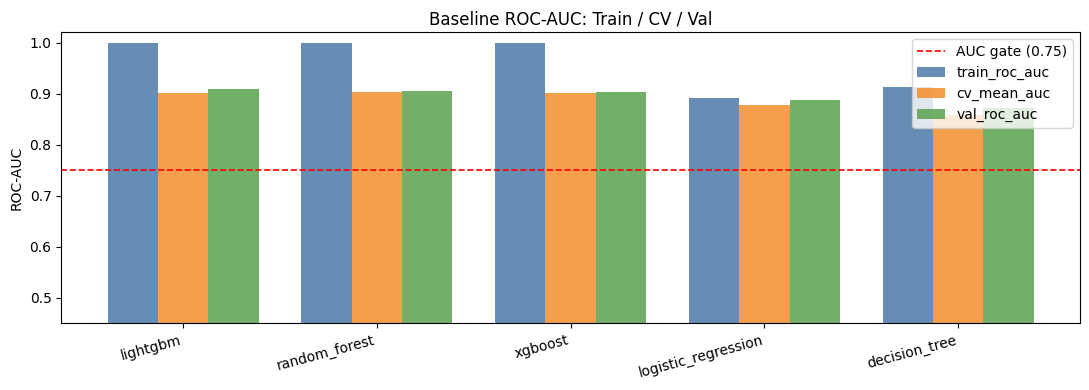

In [10]:
models_sorted = comparison_df.index.tolist()
val_aucs   = comparison_df["val_roc_auc"].tolist()
train_aucs = comparison_df["train_roc_auc"].tolist()
cv_aucs    = comparison_df["cv_mean_auc"].tolist()

x = np.arange(len(models_sorted))
w = 0.26

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(x - w, train_aucs, w, label="train_roc_auc", color="#4e79a7", alpha=0.85)
ax.bar(x,     cv_aucs,    w, label="cv_mean_auc",   color="#f28e2b", alpha=0.85)
ax.bar(x + w, val_aucs,   w, label="val_roc_auc",   color="#59a14f", alpha=0.85)
ax.axhline(AUC_GATE, color="red", linestyle="--", lw=1.2, label=f"AUC gate ({AUC_GATE})")
ax.set_xticks(x)
ax.set_xticklabels(models_sorted, rotation=15, ha="right")
ax.set_ylabel("ROC-AUC")
ax.set_title("Baseline ROC-AUC: Train / CV / Val")
ax.legend()
ax.set_ylim(0.45, 1.02)
fig.tight_layout()
plt.show()

## Section 6 â€” Champion Selection & AUC Gate

In [11]:
champion_name   = comparison_df["val_roc_auc"].idxmax()
champion_auc    = float(comparison_df.loc[champion_name, "val_roc_auc"])
champion_run_id = mlflow_run_ids[champion_name]

print("=" * 52)
print("CHAMPION MODEL")
print("=" * 52)
print(f"Model:          {champion_name}")
print(f"val_roc_auc:    {champion_auc:.4f}")
print(f"train_roc_auc:  {comparison_df.loc[champion_name, 'train_roc_auc']:.4f}")
print(f"auc_gap:        {comparison_df.loc[champion_name, 'auc_gap']:+.4f}")
print(f"cv_mean_auc:    {comparison_df.loc[champion_name, 'cv_mean_auc']:.4f}")
print(f"val_f1_at_040:  {comparison_df.loc[champion_name, 'val_f1_at_040']:.4f}")
print(f"run_id:         {champion_run_id}")
print("=" * 52)

CHAMPION MODEL
Model:          lightgbm
val_roc_auc:    0.9090
train_roc_auc:  0.9992
auc_gap:        +0.0902
cv_mean_auc:    0.9019
val_f1_at_040:  0.7980
run_id:         8a889c2cd9074c18ae69a0d85426f9f9


In [12]:
# AUC gate: must pass before Day 6 task-specific modeling proceeds
assert champion_auc >= AUC_GATE, (
    f"AUC GATE FAILED: best val_roc_auc={champion_auc:.4f} < {AUC_GATE}. "
    "Do not proceed to Day 6. "
    "Investigate: feature leakage, temporal split integrity, class balance."
)

print(f"AUC GATE PASSED: {champion_auc:.4f} >= {AUC_GATE}")
print(f"Day 6 (task-specific modeling) may proceed.")
print(f"Champion '{champion_name}' (run_id={champion_run_id}) nominated for Optuna tuning in 03_tuning.ipynb.")

AUC GATE PASSED: 0.9090 >= 0.75
Day 6 (task-specific modeling) may proceed.
Champion 'lightgbm' (run_id=8a889c2cd9074c18ae69a0d85426f9f9) nominated for Optuna tuning in 03_tuning.ipynb.
